![Agencia de viajes](./src/img/img.png)




## **CLA Flight Intelligence**

CLA Flight Intelligence — Travel Agency India es una agencia especializada en vuelos nacionales dentro de India, un mercado donde los precios fluctúan de manera constante debido a factores como la aerolínea, la duración del trayecto, el número de escalas y, especialmente, la antelación con la que se realiza la reserva. Para ofrecer a nuestros clientes las mejores opciones posibles, necesitamos comprender cómo evolucionan los precios y anticipar cuándo es más conveniente comprar un billete.

El objetivo del proyecto es desarrollar un modelo de Machine Learning capaz de predecir el precio esperado de un vuelo nacional en India a partir de sus características principales. Esta predicción permite a CLA Flight Intelligence recomendar a los clientes si es un buen momento para reservar, identificar vuelos con precios inusualmente altos o bajos y optimizar las estrategias comerciales y de marketing de la agencia.

Aunque el dataset cubre únicamente vuelos entre el 11 de febrero y el 31 de marzo, incluye la variable más determinante en el pricing aéreo: la antelación de compra (days_left). Esto permite modelar patrones reales de comportamiento del precio en el corto plazo, suficientes para mejorar la toma de decisiones de la agencia y ofrecer recomendaciones basadas en datos.

El modelo resultante ayuda a CLA Flight Intelligence — Travel Agency India a:

- Recomendar el mejor momento para reservar un vuelo dentro de India,
- Detectar oportunidades de compra cuando un precio está por debajo de lo habitual,
- Priorizar rutas y aerolíneas con mejor relación calidad‑precio,
- Mejorar la experiencia del cliente mediante información personalizada y fundamentada en datos.

#### **Paso 0: Importar librerías**

In [71]:

# LIBRERÍAS NECESARIAS

# Python estándar
import re
import numpy as np
import pandas as pd

# Visualización 
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn: Transformadores y Preprocesado 
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline

# Scikit-Learn: Modelos-Regresion
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Scikit-Learn: Modelos-Clasificacion 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Scikit-Learn: Métricas Regresión
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Scikit-Learn: Métricas Clasificación
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    roc_auc_score
)

# Scikit-Learn: Validación 
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    cross_val_score,
    KFold
)

# Optimización 
import optuna

# Otros 
from scipy import stats
import joblib
import os
import sys
sys.path.append(os.path.abspath("./src/utils"))
import bootcampviztools as bt

pd.options.mode.copy_on_write = True

#### **Paso 1: Cargar los datos y transformar**

In [72]:
df_economy= pd.read_csv("./src/data/economy.csv")
df_eco=df_economy.copy()
df_business = pd.read_csv("./src/data/business.csv")
df_bus=df_business.copy()

In [73]:
df_eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        206774 non-null  object
 1   airline     206774 non-null  object
 2   ch_code     206774 non-null  object
 3   num_code    206774 non-null  int64 
 4   dep_time    206774 non-null  object
 5   from        206774 non-null  object
 6   time_taken  206774 non-null  object
 7   stop        206774 non-null  object
 8   arr_time    206774 non-null  object
 9   to          206774 non-null  object
 10  price       206774 non-null  object
dtypes: int64(1), object(10)
memory usage: 17.4+ MB


In [74]:
df_eco.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"


In [75]:
df_bus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        93487 non-null  object
 1   airline     93487 non-null  object
 2   ch_code     93487 non-null  object
 3   num_code    93487 non-null  int64 
 4   dep_time    93487 non-null  object
 5   from        93487 non-null  object
 6   time_taken  93487 non-null  object
 7   stop        93487 non-null  object
 8   arr_time    93487 non-null  object
 9   to          93487 non-null  object
 10  price       93487 non-null  object
dtypes: int64(1), object(10)
memory usage: 7.8+ MB


In [76]:
df_bus.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612"
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612"
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\r\n\t\t\t\t\t\t\t\t\t\t\t\t\r\n\t\t\t\t...,20:45,Mumbai,"42,220"
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\r\n\t\t\t\t\t\t\t\t\t\t\t\t\r\n\t\t\t\t...,23:55,Mumbai,"44,450"
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\r\n\t\t\t\t\t\t\t\t\t\t\t\t\r\n\t\t\t\t...,23:55,Mumbai,"46,690"


Transformer 1: Convertir duración

Añade una nueva columna llamada durantion(h) que lo que hace es convertir el formato de horas y minutos a horas decimales, ya que es más recomendable para el modelo de machine learning.

In [77]:
class DurationTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        def convert(x):
            h = re.search(r'(\d+)h', x)
            m = re.search(r'(\d+)m', x)
            hours = int(h.group(1)) if h else 0
            minutes = int(m.group(1)) if m else 0
            return hours + minutes/60
        X["duration(h)"] = X["time_taken"].apply(convert)
        return X


Transformer 2: Categorizar horas

Este tranformer convierte dep_time_cat y arr_time_cat el formato horas y minutos a Late Night, Early Morning, Morning, Afternoon y Evening por las franjas horarias que se observan en el código. Esto permite que el modelo capture patrones como:
- Los vuelos de madrugada suelen ser más baratos 
- Los vuelos de tarde suelen ser más caros
- Las aerolineas ajustan precios según la franja horaria.

In [78]:
class TimeCategoryTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X["dep_time"] = pd.to_datetime(X["dep_time"], format="%H:%M")
        X["arr_time"] = pd.to_datetime(X["arr_time"], format="%H:%M")

        def categorize(h):
            if 0 <= h < 4: return "Late Night"
            if 4 <= h < 8: return "Early Morning"
            if 8 <= h < 12: return "Morning"
            if 12 <= h < 16: return "Afternoon"
            if 16 <= h < 20: return "Evening"
            return "Night"

        X["dep_time_cat"] = X["dep_time"].dt.hour.apply(categorize)
        X["arr_time_cat"] = X["arr_time"].dt.hour.apply(categorize)
        return X


Transformer 3: Limpiar stops

Este tranformer crea una variable numérica con el número de escalas del vuelo.

In [79]:
class StopCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        def clean(x):
            x = x.lower().strip()
            if "non" in x: return "non-stop"
            m = re.search(r'(\d+)', x)
            if m: return f"{m.group(1)}-stop"
            return "unknown"
        X["stop"] = X["stop"].apply(clean)
        X["stop_num"] = X["stop"].replace({
            "non-stop": 0,
            "1-stop": 1,
            "2-stop": 2
        }).astype(int)
        return X


Transformer 4: Calcular days_left

Este tranformer cuenta los días de antelación con los que se compra el billete. Aquí como no tenemos el día exactto del scrapeo se pregunta a negocio y nos dicen que el día 10 de febrero es cuando se hicieron todos los scrapeos.

In [80]:
class DaysLeftTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, scraping_date="10-02-2022"):
        self.scraping_date = pd.to_datetime(scraping_date, format="%d-%m-%Y")
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X["date"] = pd.to_datetime(X["date"], format="%d-%m-%Y", errors="coerce")
        X["days_left"] = (X["date"] - self.scraping_date).dt.days
        return X


Transformer 5: Eliminar columnas irrelevantes

Este transformer se encarga de borrar las columnas que no aportan nada al machine learning.

In [81]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_drop):
        self.cols_to_drop = cols_to_drop
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])


Transformer 6: Convertir price a float

Este tranformer convierte el precio de string a float.

In [82]:
class PriceToFloat(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # convertir a float
        X["price"] = (
            X["price"]
            .astype(str)
            .str.replace(",", "")
            .astype(float)
        )

        # renombrar con unidades
        X = X.rename(columns={"price": "price (INR)"})

        return X


Tranformer 7: Agrupar las aerolíneas

Este tranformer es para agrupar aerolíneas.

In [83]:
class AirlineGrouper(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.rare_airlines = ["SpiceJet", "StarAir", "Trujet", "AirAsia"]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["airline"] = X["airline"].replace(self.rare_airlines, "Other")
        return X


Tranformer 8: Eliminar los duplicados

Este tranformer sirve para eliminar los duplicados que se generan al simplificar el modelo.

In [84]:
class DropDuplicates(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X.drop_duplicates().reset_index(drop=True)

Pipeline ETL completo dentro de sklearn

In [85]:
cols_to_drop = [
    "dep_time", "arr_time", "date", "time_taken",
    "ch_code", "num_code", "dep_hour", "arr_hour",
    "flight", "stop"
]

etl_pipeline = Pipeline([
    ("price_float", PriceToFloat()),
    ("duration", DurationTransformer()),
    ("time_cat", TimeCategoryTransformer()),
    ("stop_clean", StopCleaner()),
    ("days_left", DaysLeftTransformer()),
    ("drop_cols", ColumnDropper(cols_to_drop)),
    ("airline_group", AirlineGrouper()),
    ("drop_dupes", DropDuplicates()),
])

In [86]:
df_eco_clean = etl_pipeline.fit_transform(df_eco)
df_bus_clean = etl_pipeline.fit_transform(df_bus)

C:\Users\aquin\AppData\Local\Temp\ipykernel_17040\2693101301.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["stop_num"] = X["stop"].replace({
C:\Users\aquin\AppData\Local\Temp\ipykernel_17040\2693101301.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["stop_num"] = X["stop"].replace({


In [87]:
df_eco_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205016 entries, 0 to 205015
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   airline       205016 non-null  object 
 1   from          205016 non-null  object 
 2   to            205016 non-null  object 
 3   price (INR)   205016 non-null  float64
 4   duration(h)   205016 non-null  float64
 5   dep_time_cat  205016 non-null  object 
 6   arr_time_cat  205016 non-null  object 
 7   stop_num      205016 non-null  int64  
 8   days_left     205016 non-null  int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 14.1+ MB


In [88]:
df_eco_clean.describe()

,price (INR),duration(h),stop_num,days_left
count,205016.000000,205016.000000,205016.000000,205016.000000
mean,6588.858679,11.612586,0.929698,26.125434
std,3748.841951,7.230707,0.429435,13.523020
min,1105.000000,0.833333,0.000000,1.000000
25%,4181.000000,6.333333,1.000000,15.000000
50%,5778.000000,10.250000,1.000000,26.000000
75%,7767.000000,15.416667,1.000000,38.000000
max,42349.000000,49.833333,2.000000,49.000000


In [89]:
df_bus_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93176 entries, 0 to 93175
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   airline       93176 non-null  object 
 1   from          93176 non-null  object 
 2   to            93176 non-null  object 
 3   price (INR)   93176 non-null  float64
 4   duration(h)   93176 non-null  float64
 5   dep_time_cat  93176 non-null  object 
 6   arr_time_cat  93176 non-null  object 
 7   stop_num      93176 non-null  int64  
 8   days_left     93176 non-null  int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 6.4+ MB


In [90]:
df_bus_clean.describe()

,price (INR),duration(h),stop_num,days_left
count,93176.000000,93176.000000,93176.000000,93176.000000
mean,52596.318966,13.737102,0.927438,25.735608
std,12933.222116,6.837663,0.300905,13.626077
min,12000.000000,1.000000,0.000000,1.000000
25%,45185.000000,8.833333,1.000000,14.000000
50%,53164.000000,13.083333,1.000000,26.000000
75%,60396.000000,17.833333,1.000000,38.000000
max,123071.000000,47.750000,2.000000,49.000000


#### **Paso 2: Mini-EDA**

**Análisis del target**

In [91]:
class TargetExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, target):
        self.target = target
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X[[self.target]]


Economy

In [92]:
target = 'price (INR)'

target_pipeline = Pipeline([
    ('extract_target', TargetExtractor(target=target))
])

target_df = target_pipeline.fit_transform(df_eco_clean)


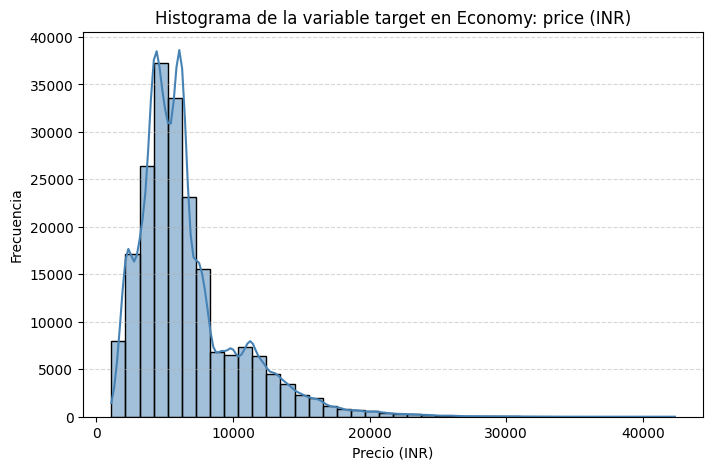

In [93]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=target_df,
    x=target,
    bins=40,
    kde=True,
    color='steelblue',
    edgecolor='black',   # ← bordes para que se vean las casillas
    linewidth=1
)

plt.title("Histograma de la variable target en Economy: price (INR)")
plt.xlabel("Precio (INR)")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


**Distribución de precios en Economy:** variabilidad moderada y estructura compacta
- La distribución de economy presenta:
    - Media: 6 588 INR
    - Desviación estándar: 3 748 INR
    - IQR: 3 586 INR
    - Máximo: 42 349 INR

- Esto describe una distribución:
    - asimétrica a la derecha, pero relativamente contenida,
    - con la mayor parte de los valores entre 4 000 y 10 000 INR,
    - con una cola larga, pero no extrema,
    - con una variabilidad moderada (std ≈ 57% de la media).

En términos estadísticos, economy es un problema más estable, con menos dispersión y menos valores extremos. Los modelos pueden aprender patrones relativamente homogéneos.

Business

In [94]:
target_df_bus = target_pipeline.fit_transform(df_bus_clean)

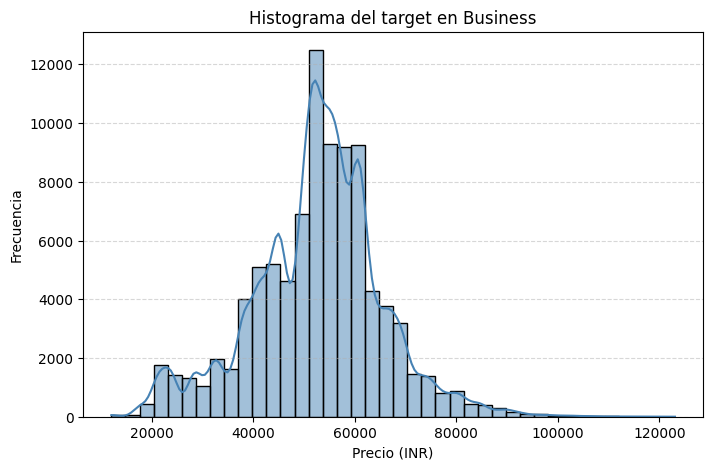

In [95]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=target_df_bus,
    x=target,
    bins=40,
    kde=True,
    color='steelblue',
    edgecolor='black',
    linewidth=1
)

plt.title("Histograma del target en Business")
plt.xlabel("Precio (INR)")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


**Distribución de precios en Business:** dispersión extrema y cola muy larga. Business es completamente distinto:

- Media: 52 540 INR
- Desviación estándar: 12 969 INR
- IQR: 15 211 INR
- Máximo: 123 071 INR

Esto implica:

- una distribución mucho más dispersa,

- una cola derecha extremadamente larga,

- valores altos frecuentes y totalmente reales,

- una variabilidad enorme (std ≈ 25% de la media, pero en términos absolutos muy grande),

- un rango intercuartílico cuatro veces mayor que en economy.

Business no es simplemente “más caro”: es más variable, más inestable y más difícil de modelar. La dispersión es tan grande que los modelos necesitan hiperparámetros distintos, regularización distinta y validación más cuidadosa.

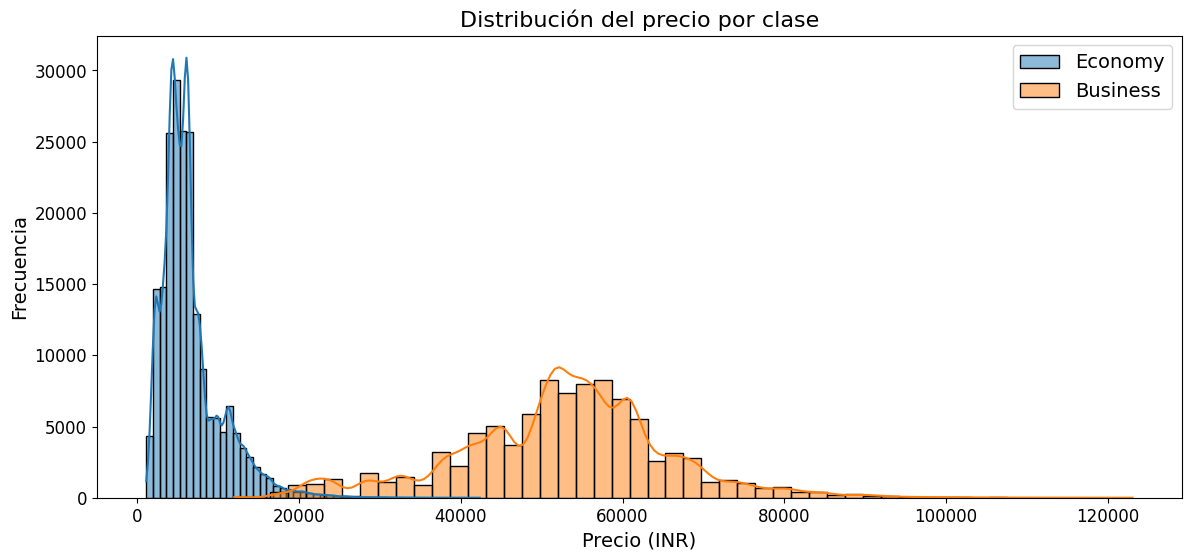

In [96]:
plt.figure(figsize=(14, 6))
sns.histplot(df_eco_clean[target], bins=50, kde=True, label = "Economy")
sns.histplot(df_bus_clean[target], bins=50, kde=True, label = "Business")
plt.title("Distribución del precio por clase", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Precio (INR)", fontsize=14)
plt.ylabel("Frecuencia", fontsize=14)
plt.legend(fontsize=14)
plt.show()

**Separar los modelos de economy y business no es solo una decisión práctica: es una consecuencia directa y obligada de cómo se distribuyen sus precios. Las dos distribuciones mostradas (sus histogramas) y sus estadísticas descriptivas revelan que estamos ante dos problemas estadísticos completamente distintos, con niveles de dispersión, varianza y estructura radicalmente diferentes. Esa diferencia es la que justifica, de forma técnica y sólida, entrenar dos modelos independientes.**

**Análisis univariante**

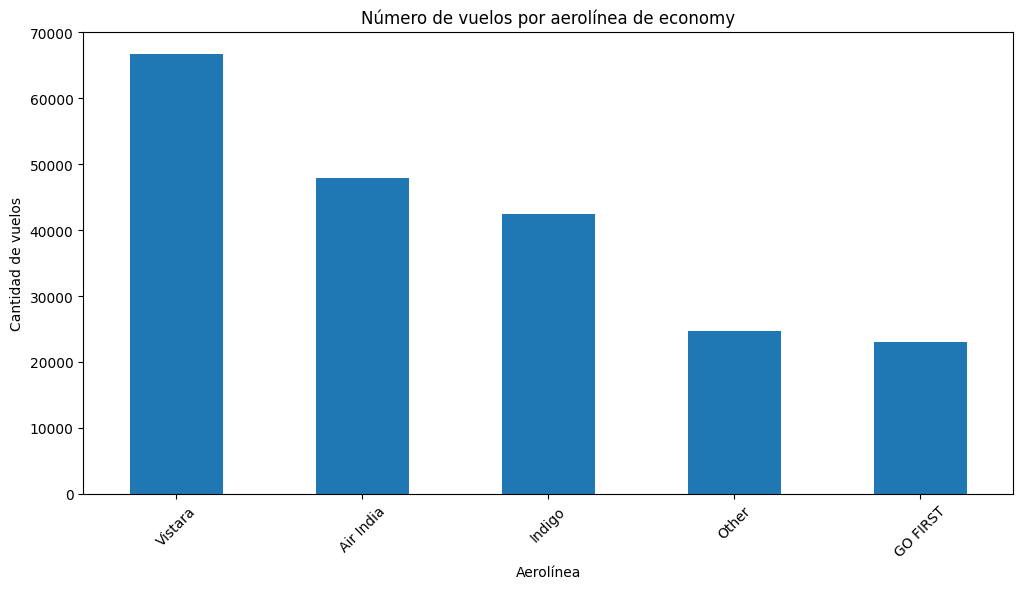

In [97]:
plt.figure(figsize=(12,6))
df_eco_clean['airline'].value_counts().plot(kind='bar')
plt.title("Número de vuelos por aerolínea de economy")
plt.xlabel("Aerolínea")
plt.ylabel("Cantidad de vuelos")
plt.xticks(rotation=45)
plt.show()


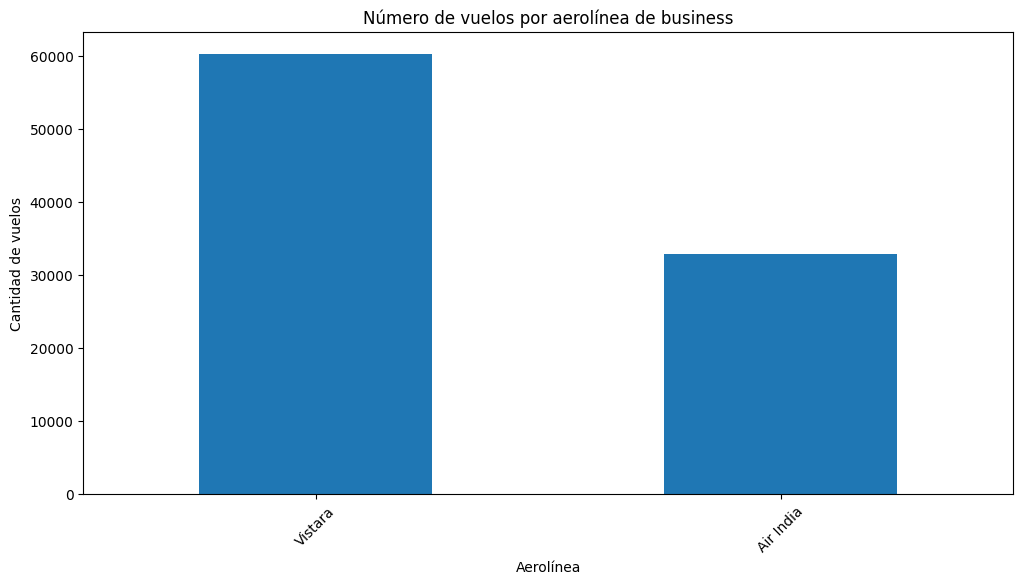

In [98]:
plt.figure(figsize=(12,6))
df_bus_clean['airline'].value_counts().plot(kind='bar')
plt.title("Número de vuelos por aerolínea de business")
plt.xlabel("Aerolínea")
plt.ylabel("Cantidad de vuelos")
plt.xticks(rotation=45)
plt.show()


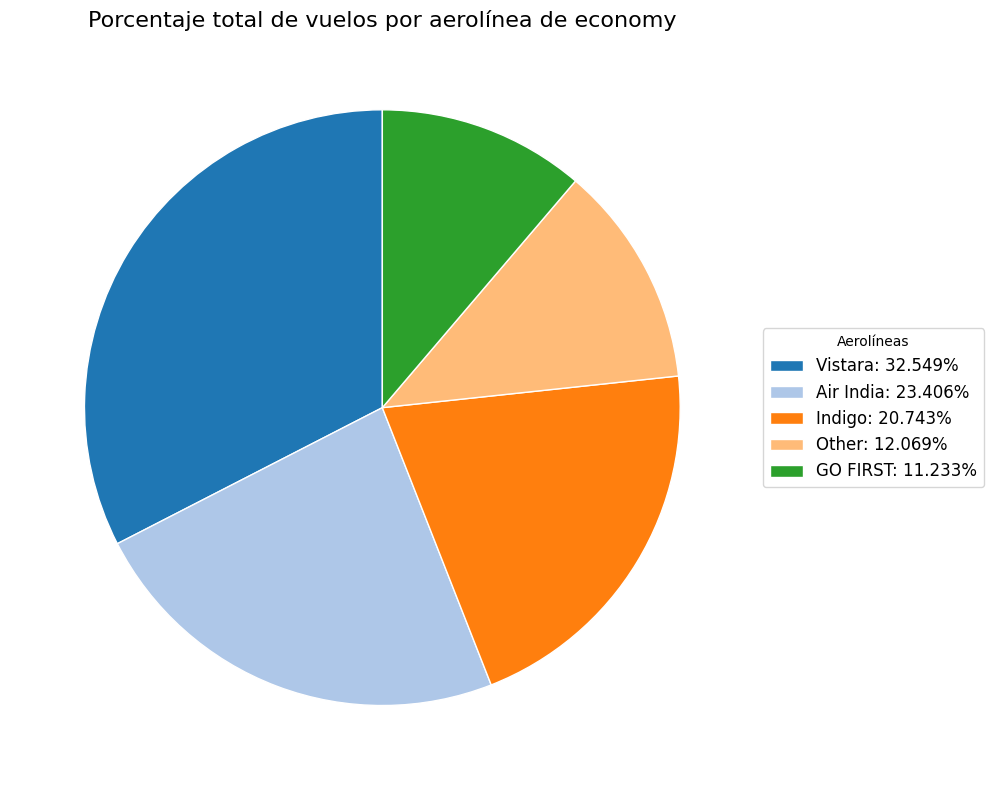

In [99]:
# Conteo y porcentaje
counts = df_eco_clean["airline"].value_counts()
percent = counts / counts.sum() * 100

plt.figure(figsize=(10, 8))

# Pie chart
plt.pie(
    counts,
    startangle=90,
    colors=sns.color_palette("tab20"),
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

# Leyenda con porcentajes (3 decimales)
labels = [f"{airline}: {pct:.3f}%" for airline, pct in zip(counts.index, percent)]
plt.legend(
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    title="Aerolíneas"
)

plt.title("Porcentaje total de vuelos por aerolínea de economy", fontsize=16)
plt.tight_layout()
plt.show()


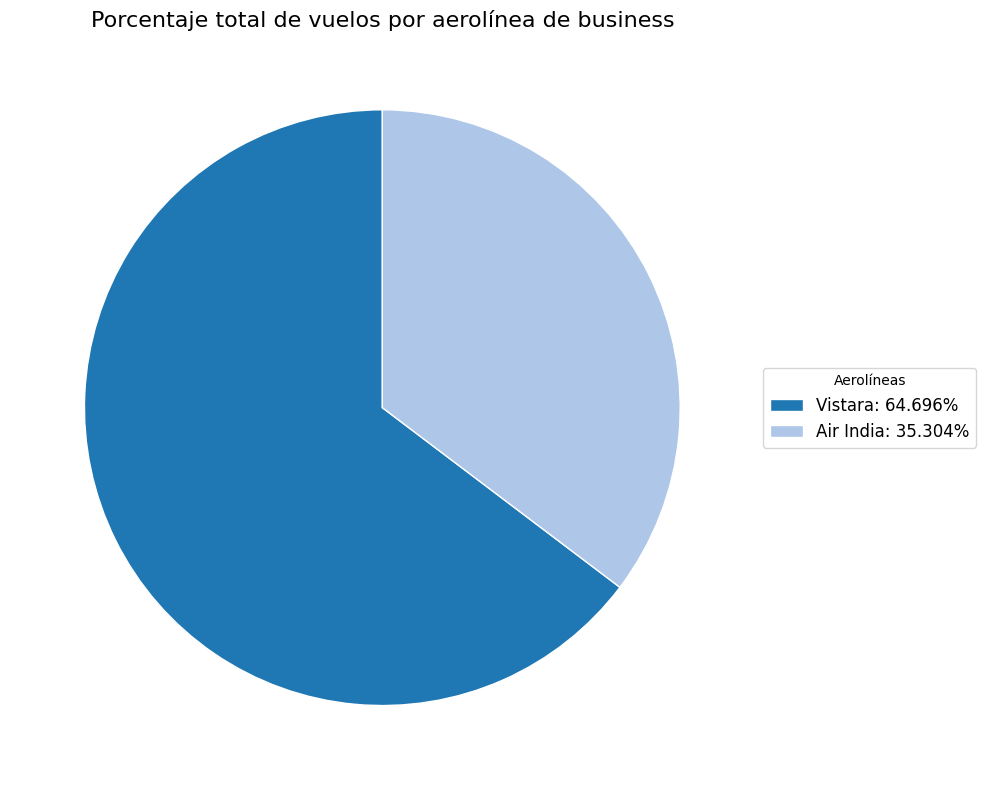

In [100]:
# Conteo y porcentaje
counts = df_bus_clean["airline"].value_counts()
percent = counts / counts.sum() * 100

plt.figure(figsize=(10, 8))

# Pie chart
plt.pie(
    counts,
    startangle=90,
    colors=sns.color_palette("tab20"),
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

# Leyenda con porcentajes (3 decimales)
labels = [f"{airline}: {pct:.3f}%" for airline, pct in zip(counts.index, percent)]
plt.legend(
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    title="Aerolíneas"
)

plt.title("Porcentaje total de vuelos por aerolínea de business", fontsize=16)
plt.tight_layout()
plt.show()


Para ver relaciones lineales utilizamos la matriz de correlación

In [101]:
class CorrelationTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        df_num = X[self.columns]
        corr_matrix = df_num.corr()
        return corr_matrix


In [102]:
num_cols = ['price (INR)', 'duration(h)', 'stop_num', 'days_left']

corr_pipeline = Pipeline([
    ('corr', CorrelationTransformer(columns=num_cols))
])

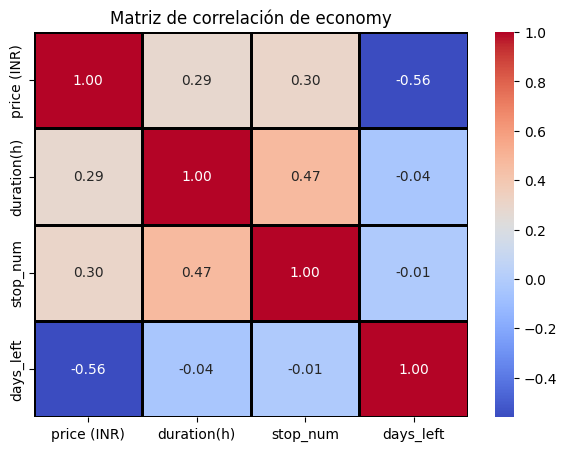

In [103]:
# Ejecutar pipeline
corr_matrix = corr_pipeline.fit_transform(df_eco_clean)

# Heatmap con casillas independientes
plt.figure(figsize=(7,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=1,      # ← bordes entre casillas
    linecolor='black'  # ← color de los bordes
)
plt.title("Matriz de correlación de economy")
plt.show()


Conclusiones de la Matriz de Economy:

1) La variable más importante es days_left (−0.56):
Cuantos más días faltan para el vuelo, más barato es.
    - Es la relación más fuerte de toda la matriz.
    - Esto confirma un patrón real del mercado aéreo:
    - Comprar con antelación → precios bajos
    - Comprar cerca de la fecha → precios altos

- Para nuestro modelo, esto significa que days_left es una de las features más predictivas.

2) Duración y número de escalas influyen, pero moderadamente (0.29 y 0.30):
Ambas correlaciones son positivas:

    - Más duración → precio más alto
    - Más escalas → precio más alto. En India, muchas escalas se producen porque:

        - no existe vuelo directo entre dos ciudades,
        - la aerolínea conecta vía Delhi, Mumbai o Bangalore,
        - la ruta total es más larga,
        - el vuelo final es más demandado.

- Esto hace que las escalas no sean “baratas”, sino rutas más largas y caras.

- Pero la correlación no es muy alta, lo que indica que:

    - No todos los vuelos largos son caros
    - No todas las escalas encarecen igual
    - Hay variabilidad por aerolínea y ruta
    - El modelo necesita estas variables, pero no son tan determinantes como days_left.

3) Duración y escalas están relacionadas entre sí (0.47)
Esto es lógico:

- Más escalas → más tiempo total de viaje

- Vuelos directos → duración más corta

- Esto implica que hay redundancia parcial entre estas dos variables.
- Los modelos basados en árboles lo manejan bien, pero es bueno saberlo.

Conclusiones sobre la estructura del dataset de Economy: 

- No hay correlaciones extremadamente altas (≥0.8). Esto es bueno:

    - No hay multicolinealidad fuerte
    - No es necesario eliminar variables
    - El modelo puede aprender relaciones complementarias

- La matriz confirma que economy tiene variabilidad moderada

- El precio no depende de una sola variable.

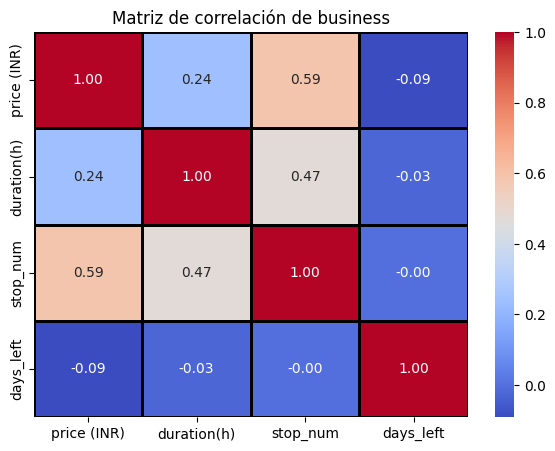

In [104]:
# Ejecutar pipeline
corr_matrix = corr_pipeline.fit_transform(df_bus_clean)

# Heatmap con casillas independientes
plt.figure(figsize=(7,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=1,      # ← bordes entre casillas
    linecolor='black'  # ← color de los bordes
)
plt.title("Matriz de correlación de business")
plt.show()

Conclusión de matriz de correlación de Business:

1) Relación principal: stop_num es el factor más asociado al precio (0.59)
Esta es la correlación más alta de toda la matriz. Significa que:

    - En business, los vuelos con más escalas tienden a ser más caros, no más baratos.
    - Esto ocurre porque las escalas en business no son “low‑cost”; suelen aparecer en rutas largas, premium o con poca oferta directa.
    - Muchas escalas en business implican conexiones operadas por aerolíneas premium (Air India, Vistara), lo que eleva el precio.

- Conclusión:  En business, stop_num es una variable clave y explica una parte importante del precio.

2) days_left casi no influye en business (–0.09). A diferencia de economy (donde days_left era la variable más importante), en business:

    - La correlación es muy débil.
    - Comprar con antelación no abarata tanto.
    - Los precios de business son más estables y menos sensibles al tiempo restante.

- Esto refleja un comportamiento real del mercado:

    - Los pasajeros business suelen comprar tarde y aun así pagan tarifas altas.
    - Las aerolíneas mantienen precios elevados incluso con mucha antelación.

- Conclusión: El precio de business depende poco del momento de compra.

3) duration(h) tiene una relación débil con el precio (0.24). Aunque intuitivamente los vuelos más largos deberían ser más caros, en business:

    - La correlación es baja.
    - La duración no explica bien el precio.
    - Esto ocurre porque muchas rutas largas tienen tarifas corporativas negociadas o precios más estables.

- Conclusión: La duración aporta información, pero no es determinante.

4) stop_num y duration están relacionados entre sí (0.47). Esto indica que:

    - Más escalas → más duración total del viaje.
    - Pero la relación no es perfecta, porque algunas escalas son cortas y otras muy largas.

- Conclusión:  Hay cierta redundancia entre ambas variables, pero cada una aporta algo distinto.

- No hay multicolinealidad fuerte. Ninguna correlación supera 0.8, lo cual es bueno:
    - No necesitas eliminar variables.
    - Los modelos basados en árboles (XGB, LGBM) pueden aprender relaciones complejas sin problema.

In [105]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

# Variables numéricas
features_num_reg = ["duration(h)", "days_left", "stop_num"]

# Separar X e y para economy
X_eco_num = df_eco_clean[features_num_reg]
y_eco = df_eco_clean["price (INR)"]

# Calcular MI
mi_eco = mutual_info_regression(X_eco_num, y_eco, random_state=42)

# Crear tabla ordenada
mi_eco_df = pd.DataFrame({
    "feature": features_num_reg,
    "mutual_information": mi_eco
}).sort_values(by="mutual_information", ascending=False)

print("Mutual Information - ECONOMY")
print(mi_eco_df)


Mutual Information - ECONOMY
       feature  mutual_information
0  duration(h)            2.235380
1    days_left            0.635302
2     stop_num            0.402596


In [106]:
# Separar X e y para business
X_bus_num = df_bus_clean[features_num_reg]
y_bus = df_bus_clean["price (INR)"]

# Calcular MI
mi_bus = mutual_info_regression(X_bus_num, y_bus, random_state=42)

# Crear tabla ordenada
mi_bus_df = pd.DataFrame({
    "feature": features_num_reg,
    "mutual_information": mi_bus
}).sort_values(by="mutual_information", ascending=False)

print("Mutual Information - BUSINESS")
print(mi_bus_df)


Mutual Information - BUSINESS
       feature  mutual_information
0  duration(h)            2.744530
2     stop_num            0.320747
1    days_left            0.133846


- duration(h) es la variable más informativa en ambos modelos → aporta mucha señal.
- days_left es muy importante en Economy, pero poco en Business → comportamiento real del mercado.
- stop_num aporta menos información, pero sigue aportando → no es ruido.

Por todo esto decidimos dejar todas las variable numéricas y no quitar ninguna.

**Vamos a verificar outlier**

In [107]:
class OutlierDetectorIQR(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.num_cols = None
        self.bounds = {}
    
    def fit(self, X, y=None):
        self.num_cols = X.select_dtypes(include=['int64', 'float64']).columns
        
        for col in self.num_cols:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            self.bounds[col] = (lower, upper)
        
        return self
    
    def transform(self, X):
        X_out = X.copy()
        X_out["is_outlier"] = False
        
        for col in self.num_cols:
            lower, upper = self.bounds[col]
            mask = (X[col] < lower) | (X[col] > upper)
            X_out["is_outlier"] = X_out["is_outlier"] | mask
        
        return X_out



In [108]:
outlier_pipeline = Pipeline([
    ('outliers', OutlierDetectorIQR())
])


In [109]:
df_eco_out = outlier_pipeline.fit_transform(df_eco_clean)
df_eco_out.head()


,airline,from,to,price (INR),duration(h),dep_time_cat,arr_time_cat,stop_num,days_left,is_outlier
0,Other,Delhi,Mumbai,5953.0,2.166667,Evening,Night,0,1,True
1,Other,Delhi,Mumbai,5953.0,2.333333,Early Morning,Morning,0,1,True
2,Other,Delhi,Mumbai,5956.0,2.166667,Early Morning,Early Morning,0,1,True
3,Vistara,Delhi,Mumbai,5955.0,2.250000,Morning,Afternoon,0,1,True
4,Vistara,Delhi,Mumbai,5955.0,2.333333,Morning,Morning,0,1,True


In [110]:
df_eco_out['is_outlier'].value_counts()


is_outlier
False    153986
True      51030
Name: count, dtype: int64

In [111]:
df_bus_out = outlier_pipeline.fit_transform(df_bus_clean)
df_bus_out.head()


,airline,from,to,price (INR),duration(h),dep_time_cat,arr_time_cat,stop_num,days_left,is_outlier
0,Air India,Delhi,Mumbai,25612.0,2.000000,Evening,Night,0,1,True
1,Air India,Delhi,Mumbai,25612.0,2.250000,Evening,Night,0,1,True
2,Air India,Delhi,Mumbai,42220.0,24.750000,Night,Night,1,1,False
3,Air India,Delhi,Mumbai,44450.0,26.500000,Night,Night,1,1,False
4,Air India,Delhi,Mumbai,46690.0,6.666667,Evening,Night,1,1,False


In [112]:
df_bus_out['is_outlier'].value_counts()

is_outlier
False    82859
True     10317
Name: count, dtype: int64

In [113]:
def boxplot_variable(df, col):
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x=col, color='skyblue')
    plt.title(f"Boxplot de {col}")
    plt.show()


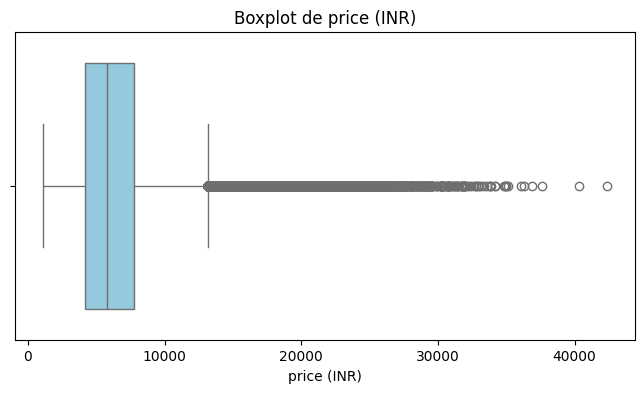

In [114]:
boxplot_variable(df_eco_clean, 'price (INR)')


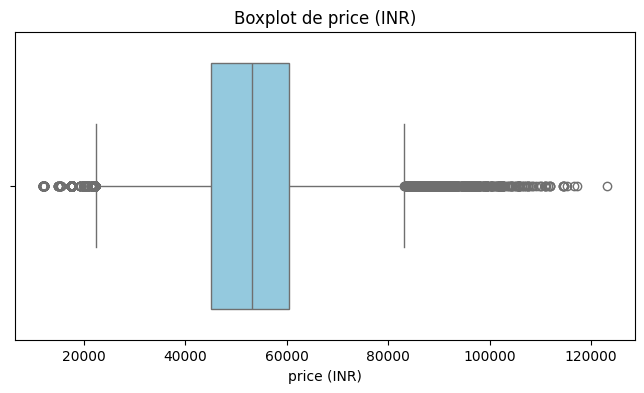

In [115]:
boxplot_variable(df_bus_clean, 'price (INR)')


El análisis exploratorio de la variable objetivo (price) en el mercado de vuelos domésticos en India reveló patrones muy marcados tanto en la clase Economy como en Business. Los boxplots y los histogramas muestran distribuciones fuertemente asimétricas hacia la derecha, con una gran concentración de precios en los rangos más bajos y la presencia de un número considerable de valores extremos.

Diferencias entre Economy y Business: 
- Economy presenta una distribución muy concentrada en precios bajos, con una mediana reducida y una cola larga hacia la derecha. Esto refleja la estructura real del mercado indio, donde la mayoría de los pasajeros viaja en tarifas económicas y solo una minoría paga precios significativamente más altos (por ejemplo, vuelos de última hora, rutas con alta demanda o aerolíneas premium).

- Business mantiene la misma asimetría, pero desplazada hacia valores más altos. Los boxplots muestran una mayor dispersión y un número notable de puntos considerados outliers desde un punto de vista estadístico, que corresponden a tarifas corporativas, vuelos en fechas pico o rutas con menor competencia.

- En ambos casos, los valores extremos no son errores ni registros anómalos: representan tarifas reales del mercado aéreo indio, donde los precios pueden variar drásticamente según la demanda, la anticipación de compra, la aerolínea o la disponibilidad.

¿Por qué no se eliminaron los outliers?

Los precios extremos observados:
- corresponden a vuelos reales (última hora, alta demanda, rutas premium),
- forman parte natural del comportamiento del mercado aéreo,
- aportan información valiosa para que el modelo aprenda patrones en situaciones de alta variabilidad.

Eliminar estos valores habría supuesto:
- perder información clave sobre el comportamiento del mercado,
- sesgar el modelo hacia tarifas medias,
- y reducir su capacidad para predecir correctamente precios altos, que son especialmente relevantes para la toma de decisiones.

Por ello, se decidió mantener todos los valores, preservando la variabilidad real del dominio.

Problema metodológico derivado: estratificación del train/test split

La fuerte asimetría del precio y la presencia de valores extremos generan un riesgo importante al dividir los datos en entrenamiento y prueba. Un split aleatorio simple podría producir:

- un conjunto de entrenamiento sin suficientes ejemplos de precios altos,
- un conjunto de prueba con una proporción desrepresentada de vuelos caros o baratos,
- y, como consecuencia, una evaluación inestable y poco representativa del rendimiento real del modelo.

Para evitar este problema se aplicó una estratificación basada en la variable objetivo.

Sin embargo, al tratarse de una variable continua, fue necesario convertirla en categorías mediante un proceso de binning.

Justificación del binning de la variable objetivo:

El binning se utilizó exclusivamente para permitir la estratificación, no como variable predictora. Su objetivo fue garantizar que tanto train como test mantuvieran proporciones similares de:

- vuelos de precio bajo (muy frecuentes),
- vuelos de precio medio,
- vuelos de precio alto (menos frecuentes pero críticos para el modelo).

Este enfoque asegura que:

- el modelo vea durante el entrenamiento ejemplos representativos de toda la distribución real del mercado,
- el conjunto de prueba no quede sesgado hacia un rango concreto de precios,
- y la evaluación final sea más robusta, estable y comparable.

Integración metodológica:

- La combinación de decisiones —mantener los outliers y estratificar mediante binning— responde a un mismo principio: preservar la estructura real del mercado aéreo indio y garantizar un proceso de modelado estable y representativo.

- Dado que el precio de los vuelos presenta colas largas y variaciones extremas legítimas, la estratificación basada en intervalos de precio es una medida necesaria para evitar particiones desequilibradas y asegurar que el rendimiento del modelo se evalúe de forma justa.

#### **Paso 3: Split Train y Test**

In [116]:
# Economy
df_eco_ml = df_eco_clean.copy()
# Business
df_bus_ml = df_bus_clean.copy()

Usamos price_bin porque es la única forma correcta de aplicar stratify en un problema de regresión, donde la variable objetivo (el precio) es continua. Stratify solo funciona con clases, no con números continuos. Crear price_bin convierte el precio en categorías artificiales que permiten equilibrar la distribución entre train y test.

Garantiza que train y test tengan la misma distribución de precios. Sin price_bin, el split aleatorio puede producir:
- train con precios bajos y test con precios altos o al revés


¿Por qué price_bin es crítico en business?

Porque Business tiene una distribución mucho más dispersa y extrema.
- Precios muy bajos (ofertas puntuales)
- Precios medios
- Precios extremadamente altos (última hora, rutas premium, aerolíneas premium)

In [117]:
df_eco_ml["price_bin"] = pd.qcut(df_eco_ml["price (INR)"], q=10, duplicates="drop")
X_eco = df_eco_ml.drop(columns=["price_bin", "price (INR)"])
y_eco = df_eco_ml["price (INR)"]


df_bus_ml["price_bin"] = pd.qcut(df_bus_ml["price (INR)"], q=10, duplicates="drop")
X_bus = df_bus_ml.drop(columns=["price_bin", "price (INR)"])
y_bus = df_bus_ml["price (INR)"]

In [118]:
X_eco_train, X_eco_test, y_eco_train, y_eco_test = train_test_split(
    X_eco, y_eco, test_size=0.2, random_state=42, stratify = df_eco_ml["price_bin"]
)

In [119]:
X_bus_train, X_bus_test, y_bus_train, y_bus_test = train_test_split(
    X_bus, y_bus, test_size=0.2, random_state=42, stratify = df_bus_ml["price_bin"]
)

#### **Paso 4: Selección de features categóricas**

In [120]:
features_num_reg = ["duration(h)", "days_left", "stop_num"]
print(features_num_reg)

features_cat_reg = [col for col in df_eco_clean.columns if col not in features_num_reg and col != target]
print(features_cat_reg)

features = features_num_reg + features_cat_reg

['duration(h)', 'days_left', 'stop_num']
['airline', 'from', 'to', 'dep_time_cat', 'arr_time_cat']


**Categóricas vs target_reg**

Economy

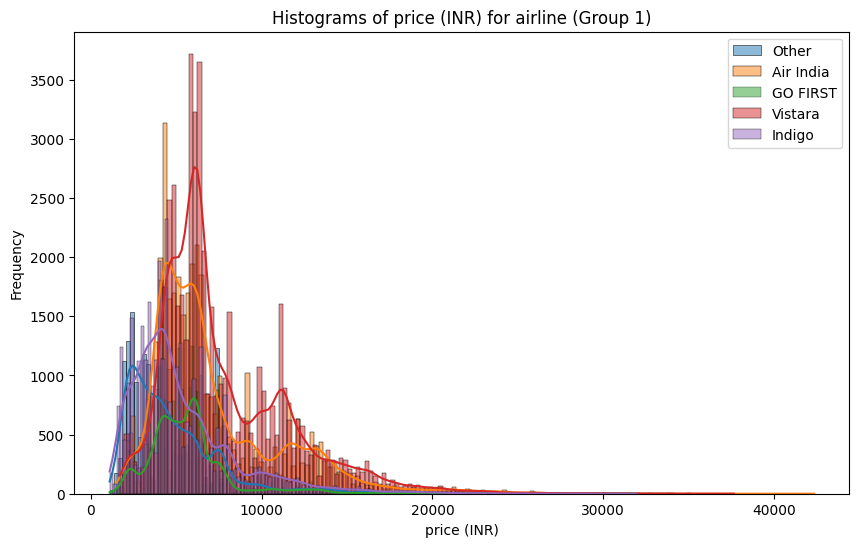

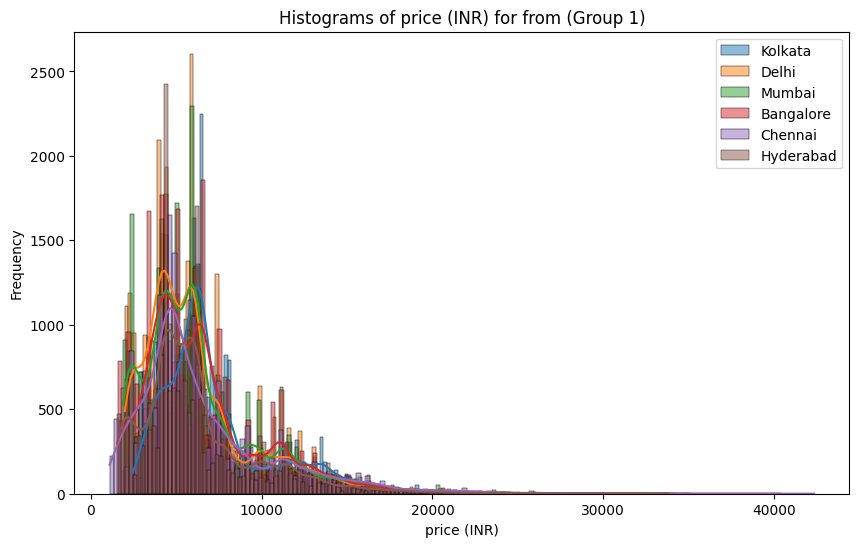

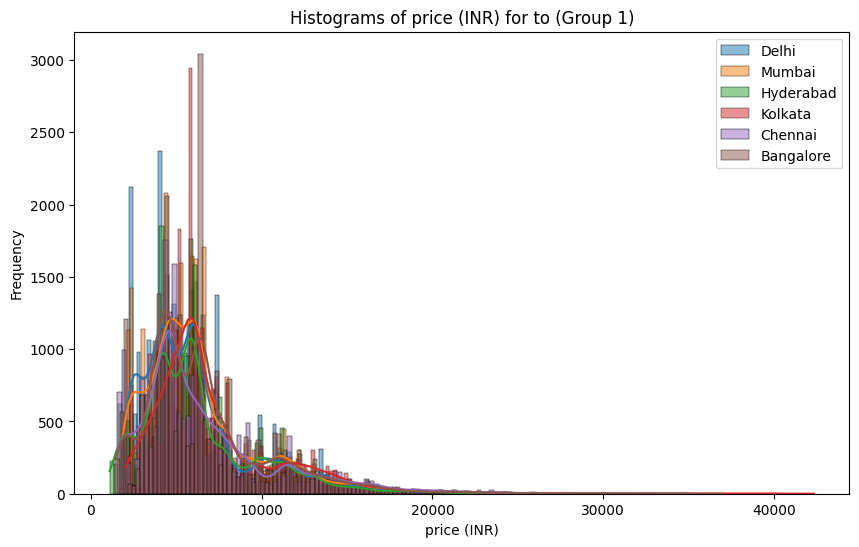

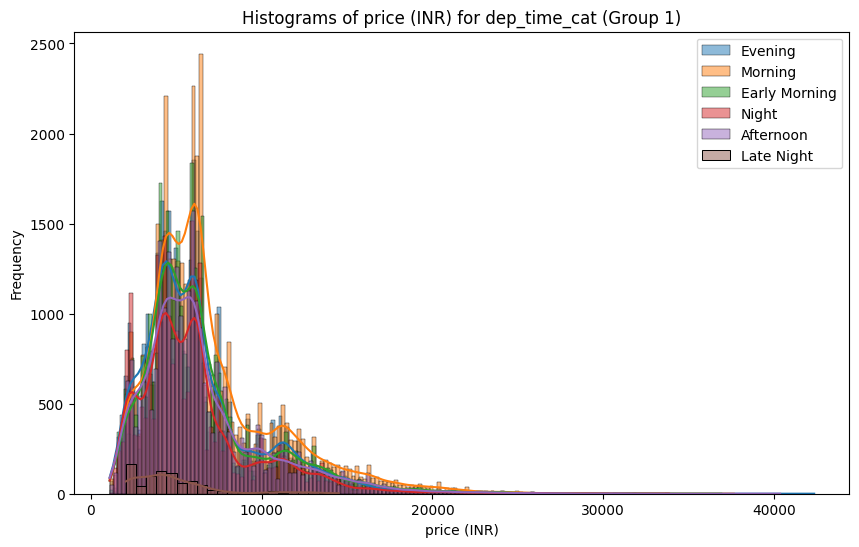

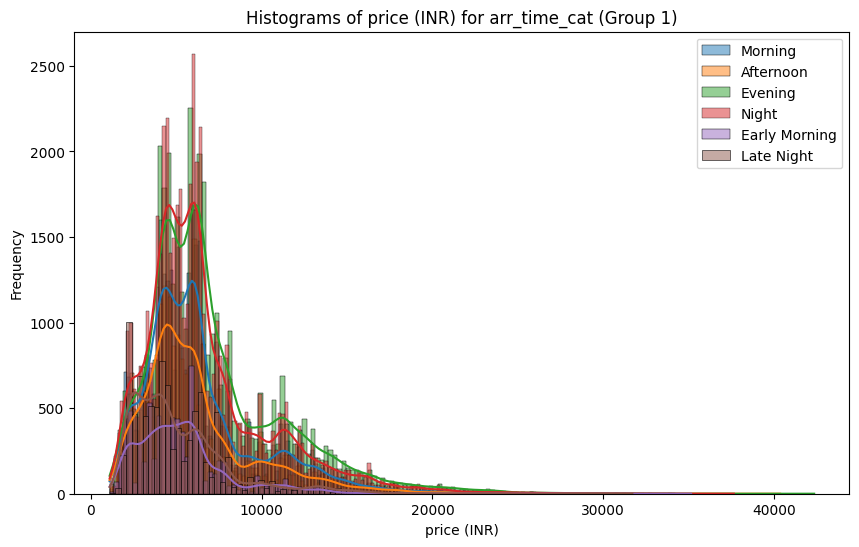

In [121]:
train_set_eco = pd.concat([X_eco_train, y_eco_train], axis = 1)

for col_cat in features_cat_reg:
    bt.plot_grouped_histograms(train_set_eco, cat_col= col_cat, num_col= target, group_size= train_set_eco[col_cat].nunique())

*Se pueden apreciar algunos cruces, pero visualmentes es complicado ver las relaciones con el target.*

Lo hacemos también con el test ANOVA para decidir si nos quedamos todas o no.

In [122]:
for cat_col in features_cat_reg:
    valores_unicos = train_set_eco[cat_col].unique()
    target_por_cat_col = [train_set_eco[train_set_eco[cat_col] == categoria][target] for categoria in valores_unicos]

    f_val, p_val = stats.f_oneway(*target_por_cat_col)
    print(f"{cat_col}:")
    print(f"\t Valor de F: {f_val}")
    print(f"\t p-valor: {p_val}")

airline:
	 Valor de F: 4567.3544097081085
	 p-valor: 0.0
from:
	 Valor de F: 399.52060125107556
	 p-valor: 0.0
to:
	 Valor de F: 226.1477229395582
	 p-valor: 2.029238256785696e-241
dep_time_cat:
	 Valor de F: 270.4684966198135
	 p-valor: 4.610231257728228e-289
arr_time_cat:
	 Valor de F: 813.7066721831753
	 p-valor: 0.0


*Todos los p-valores son muy pequeños (p-valor << 0.01), se puede rechazar la hipótesis nula de que no existe relación entre las variables, así que nos quedamos con todas.*

Business

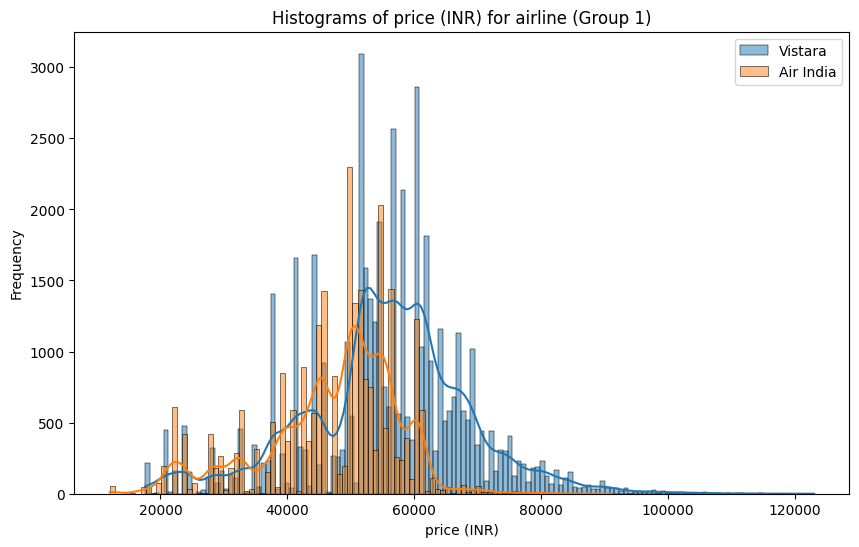

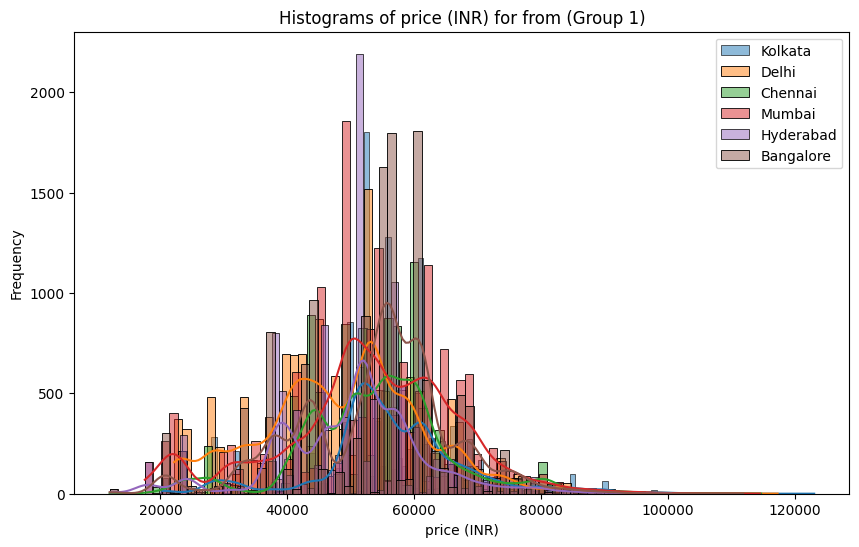

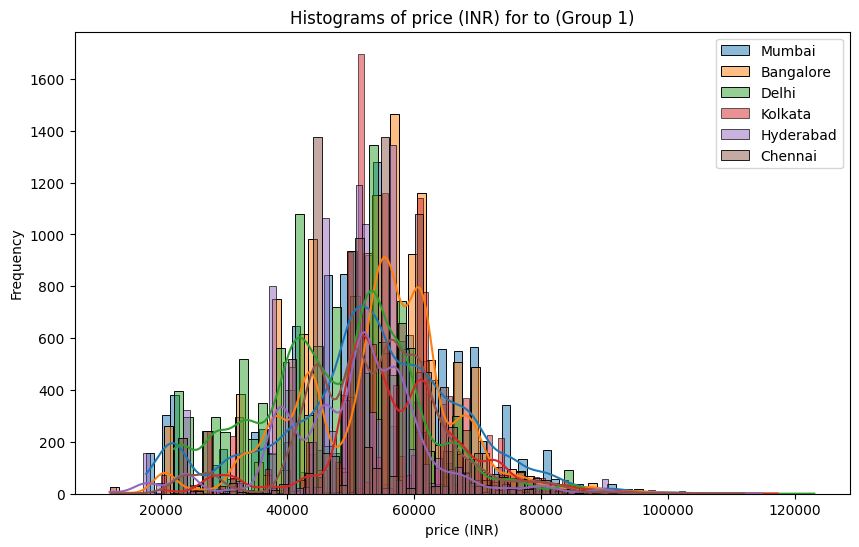

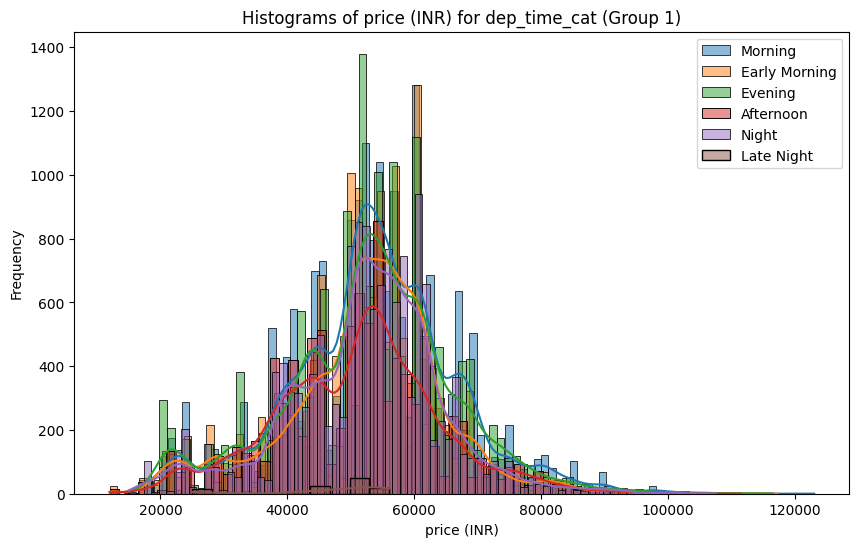

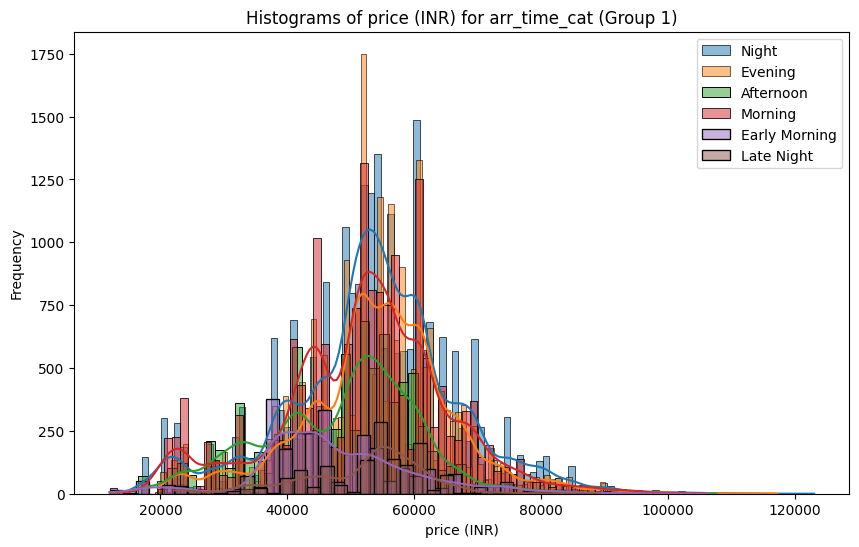

In [123]:
train_set_bus = pd.concat([X_bus_train, y_bus_train], axis = 1)

for col_cat in features_cat_reg:
    bt.plot_grouped_histograms(train_set_bus, cat_col= col_cat, num_col= target, group_size= train_set_bus[col_cat].nunique())

Lo hacemos también con el test ANOVA para decidir si nos quedamos todas o no.

In [124]:
for cat_col in features_cat_reg:
    valores_unicos = train_set_bus[cat_col].unique()
    target_por_cat_col = [train_set_bus[train_set_bus[cat_col] == categoria][target] for categoria in valores_unicos]

    f_val, p_val = stats.f_oneway(*target_por_cat_col)
    print(f"{cat_col}:")
    print(f"\t Valor de F: {f_val}")
    print(f"\t p-valor: {p_val}")

airline:
	 Valor de F: 7971.108517499392
	 p-valor: 0.0
from:
	 Valor de F: 589.4096615446055
	 p-valor: 0.0
to:
	 Valor de F: 703.1822383022915
	 p-valor: 0.0
dep_time_cat:
	 Valor de F: 58.04829753635009
	 p-valor: 1.6526684260062768e-60
arr_time_cat:
	 Valor de F: 376.43849742339063
	 p-valor: 0.0


*De nuevo todos los p-valores son muy pequeños (p-valor << 0.01), se puede rechazar la hipótesis nula de que no existe relación entre las variables, así que nos quedamos con todas.*

#### **Paso 5: Tratamiento de features**

Codificamos las variables categóricas con OneHotEncoder. Las variables numéricas no las vamos a tratar ya que no usamos modelos que lo necesiten y además no ayudan en nuestro caso.

In [125]:
preprocessor_trees = ColumnTransformer([
    ("procesar_cat_OH", OneHotEncoder(handle_unknown = "ignore"), features_cat_reg)
], remainder = "passthrough")

#### **Paso 6: Baseline**

RMSE será la métrica principal de evaluación, ya que nos interesa penalizar los errores grandes de predicción del target, y se usará de manera complementaria el MAE y el R2 score.

In [126]:
def eval_cv(model, X, y, name):
    '''
    Función que calcula las medias del cv para RMSE, MAE y R2
    '''
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }

    cv = cross_validate(
        model,
        X,
        y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    print(f"\nModel <{name}>")
    print("RMSE_CV:", -cv["test_rmse"].mean())
    print("MAE_CV:", -cv["test_mae"].mean())
    print("R2_CV:", cv["test_r2"].mean())


In [127]:
def eval_test(model, X_test, y_test, name):
    '''
    Función para evaluar contra test
    '''
    preds = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"\nTest results <{name}>")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)


Creamos el pipeline para el modelo base RandomForest

**Randomforest (Baseline):** Elegimos Randomforest como baseline porque es un modelo sencillo de entrenar, rápido, robusto, no requiere escalado, maneja no linealidades y es fácil de interpretar.

In [128]:
rf_eco = Pipeline([
    ("prep", preprocessor_trees),
    ("model", RandomForestRegressor(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_bus = Pipeline([
    ("prep", preprocessor_trees),
    ("model", RandomForestRegressor(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

#### **Paso 7: Comparación modelos**

Aquí creamos el pipeline de los otros modelos con sus diferentes parámetros

**XGBoost**

In [129]:
xgb_eco = Pipeline([
    ("prep", preprocessor_trees),
    ("model", XGBRegressor(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_bus = Pipeline([
    ("prep", preprocessor_trees),
    ("model", XGBRegressor(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

**LightGBM**

In [130]:
lgbm_eco = Pipeline([
    ("prep", preprocessor_trees),
    ("model", LGBMRegressor(
        max_depth = 5,
        random_state=42
    ))
])

lgbm_bus = Pipeline([
    ("prep", preprocessor_trees),
    ("model", LGBMRegressor(
        max_depth = 5,
        random_state=42
    ))
])

Aquí realizamos la validación cruzada, que es un mecanismo que permite estimar el rendimiento real del modelo usando únicamente el conjunto de entrenamiento, sin mirar el test.

Economy

In [131]:
eval_cv(rf_eco, X_eco_train, y_eco_train, "RF Economy")
eval_cv(xgb_eco, X_eco_train, y_eco_train, "XGB Economy")
eval_cv(lgbm_eco, X_eco_train, y_eco_train, "LGBM Economy")


Model <RF Economy>
RMSE_CV: 2240.0646347702996
MAE_CV: 1465.6140788521957
R2_CV: 0.643190746752518

Model <XGB Economy>
RMSE_CV: 1771.078227285551
MAE_CV: 1103.8983281960413
R2_CV: 0.7769529651686733

Model <LGBM Economy>
RMSE_CV: 1907.2029262108076
MAE_CV: 1218.929477653392
R2_CV: 0.7413601471154718


Una vez obsaervado los resultados de Economy de la validacion cruzada nos quedamos con el modelo XGB porque es el que mejor metricas tiene. Pero tanto el modelo XGB como LGBM tiene mejores metricas que el Baseline.

Business

In [132]:
eval_cv(rf_bus, X_bus_train, y_bus_train, "RF Business")
eval_cv(xgb_bus, X_bus_train, y_bus_train, "XGB Business")
eval_cv(lgbm_bus, X_bus_train, y_bus_train, "LGBM Business")


Model <RF Business>
RMSE_CV: 8811.834374042919
MAE_CV: 6473.079786959258
R2_CV: 0.5368208716003515

Model <XGB Business>
RMSE_CV: 5536.26743448597
MAE_CV: 3826.0793652238945
R2_CV: 0.8171829476348916

Model <LGBM Business>
RMSE_CV: 6715.443132763452
MAE_CV: 4842.106297597782
R2_CV: 0.7310104504900885


Una vez obsaervado los resultados de Business de la validación cruzada nos quedamos con el modelo XGB porque es el que mejor métricas tiene. Pero tanto el modelo XGB como LGBM tiene mejores métricas que el Baseline.

#### **Paso 8: Optimización con optuna**

Optimizamos con optuna XGBoost tanto para economy como para business.

Economy

In [133]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "model__n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "model__max_depth": trial.suggest_int("max_depth", 3, 8), 
        "model__learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "model__subsample": trial.suggest_float("subsample", 0.5, 1),
        "model__colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0)
    }

    xgb_eco.set_params(**param_grid)

    score = cross_val_score(
        xgb_eco,
        X_eco_train,
        y_eco_train,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [134]:
# Crear y ejecutar estudy de Optuna
study_eco_xgb = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

[I 2026-03-04 20:25:23,428] A new study created in memory with name: no-name-65f82dad-42d4-4164-a62f-2813baaa4da5


In [135]:
study_eco_xgb.optimize(objective, n_trials= 100) # optimizar el estudio

[I 2026-03-04 20:25:41,878] Trial 0 finished with value: 1518.58394457636 and parameters: {'n_estimators': 362, 'max_depth': 8, 'learning_rate': 0.07587945476302646, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182}. Best is trial 0 with value: 1518.58394457636.
[I 2026-03-04 20:25:46,771] Trial 1 finished with value: 2022.367190653063 and parameters: {'n_estimators': 209, 'max_depth': 3, 'learning_rate': 0.08795585311974417, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227}. Best is trial 0 with value: 1518.58394457636.
[I 2026-03-04 20:25:53,350] Trial 2 finished with value: 1682.1889987623847 and parameters: {'n_estimators': 114, 'max_depth': 8, 'learning_rate': 0.08491983767203796, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503}. Best is trial 0 with value: 1518.58394457636.
[I 2026-03-04 20:25:59,532] Trial 3 finished with value: 1972.8302564038372 and parameters: {'n_estimators': 228, 'max_depth': 4, 'learning

A continuación vemos el mejor trial, el mejor valor, los mejores parámetros y guardamos ese modelo con dichos parámetros.

In [136]:
study_eco_xgb.best_trial

FrozenTrial(number=75, state=<TrialState.COMPLETE: 1>, values=[1377.961383404414], datetime_start=datetime.datetime(2026, 3, 4, 21, 2, 37, 463761), datetime_complete=datetime.datetime(2026, 3, 4, 21, 3, 12, 647379), params={'n_estimators': 741, 'max_depth': 8, 'learning_rate': 0.08921360833085491, 'subsample': 0.9082882379967864, 'colsample_bytree': 0.9017673357116589}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=800, log=False, low=100, step=1), 'max_depth': IntDistribution(high=8, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.1, log=False, low=0.01, step=None), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.5, step=None)}, trial_id=75, value=None)

In [137]:
study_eco_xgb.best_value

1377.961383404414

In [138]:
best_params_eco_xgb = study_eco_xgb.best_params
best_params_eco_xgb

{'n_estimators': 741,
 'max_depth': 8,
 'learning_rate': 0.08921360833085491,
 'subsample': 0.9082882379967864,
 'colsample_bytree': 0.9017673357116589}

In [139]:
best_params_eco_pipe = {f"model__{k}": v for k, v in best_params_eco_xgb.items()}

In [140]:
xgb_eco.set_params(**best_params_eco_pipe)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('procesar_cat_OH', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [142]:
joblib.dump(xgb_eco, "./src/models/xgb_best_model_eco_2.joblib")

['./src/models/xgb_best_model_eco_2.joblib']

In [143]:
best_xgb_eco = joblib.load("./src/models/xgb_best_model_eco_2.joblib")

In [144]:
best_xgb_eco.fit(X_eco_train, y_eco_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('procesar_cat_OH', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

Evaluación:

In [145]:
eval_test(best_xgb_eco, X_eco_test, y_eco_test, "XGB Economy")


Test results <XGB Economy>
RMSE: 1324.5472633201887
MAE: 730.7947203997414
R2: 0.8747750552261185


In [165]:
def eval_test_with_parity_plot(model, X_test, y_test, name):
    # 1. Obtener predicciones
    preds = model.predict(X_test)

    # 2. Calcular métricas de regresión
    rmse = root_mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"\nTest results <{name}>")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R2:   {r2:.4f}")

    # 3. Crear el Parity Plot
    plt.figure(figsize=(8, 8))
    
    # Scatter plot de puntos negros
    plt.scatter(y_test, preds, c='black', alpha=0.5, s=20, label='Predicciones')
    
    # Línea de referencia (y = x) en rojo
    max_val = max(max(y_test), max(preds))
    min_val = min(min(y_test), min(preds))
    plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, label='Referencia Perfecta')

    # Líneas auxiliares (dashlines) al 10% en azul
    # y = x * 1.1 y y = x * 0.9
    x_range = np.linspace(min_val, max_val, 100)
    plt.plot(x_range, x_range * 1.4, color='blue', linestyle='--', alpha=0.7, label='+40% Varianza')
    plt.plot(x_range, x_range * 0.6, color='blue', linestyle='--', alpha=0.7, label='-40% Varianza')
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    # Configuración de tamaños de fuente
    plt.title(f'Parity Plot: {name}', fontsize=16)
    plt.xlabel('Valores Reales', fontsize=14)
    plt.ylabel('Valores Predichos', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


Test results <XGB Economy>
RMSE: 1324.55
MAE:  730.79
R2:   0.8748


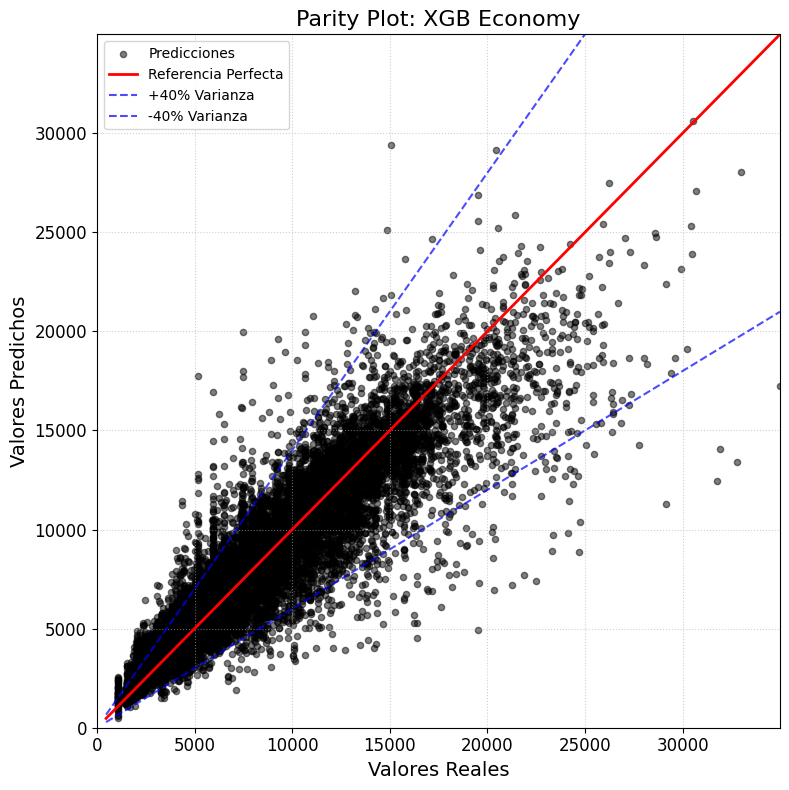

In [166]:
eval_test_with_parity_plot(best_xgb_eco, X_eco_test, y_eco_test, "XGB Economy")

Para evaluar el rendimiento del modelo se dividió el conjunto de datos en un 80% para entrenamiento y un 20% para test mediante un train/test split. Sobre el 80% de entrenamiento se aplicó validación cruzada con el objetivo de obtener estimaciones robustas del rendimiento sin utilizar el conjunto de test.

En primer lugar, la validación cruzada del modelo XGBoost sin optimizar obtuvo un RMSE de 1771 INR ($\approx$ 17€), lo que permitió compararlo con otros modelos base (Random Forest y LightGBM) y seleccionar el más prometedor antes de realizar cualquier ajuste.

Posteriormente, se llevó a cabo una optimización de hiperparámetros mediante Optuna, también utilizando únicamente el 80% de entrenamiento. Esta optimización redujo el RMSE medio de validación cruzada a 1377 INR ($\approx$ 13€), evidenciando una mejora significativa del modelo dentro del conjunto de entrenamiento.

Finalmente, el modelo optimizado se entrenó con todo el conjunto de entrenamiento (el 80% original) y se evaluó una única vez sobre el 20% reservado para test, obteniendo un RMSE de 1329 INR ($\approx$ 13€). La proximidad entre el RMSE de validación cruzada (1377) y el RMSE de test (1329) indica que el modelo generaliza correctamente a datos no vistos, sin signos de overfitting ni underfitting. Esto confirma que el rendimiento observado en el conjunto de test es coherente con el comportamiento estimado durante la validación cruzada y valida la calidad del modelo final

Business

In [ ]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "model__n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "model__max_depth": trial.suggest_int("max_depth", 3, 8),  # 5 y 15
        "model__learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1), # 0.05 y 1
        "model__subsample": trial.suggest_float("subsample", 0.5, 1),
        "model__colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0)
    }

    xgb_bus.set_params(**param_grid)

    score = cross_val_score(
        xgb_bus,
        X_bus_train,
        y_bus_train,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [ ]:
# Crear y ejecutar estudy de Optuna
study_bus = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

In [ ]:
study_bus.optimize(objective, n_trials= 100) # optimizar el estudio

A continuación vemos el mejor trial, el mejor valor, los mejores parámetros y guardamos ese modelo con dichos parámetros.

In [ ]:
study_bus.best_trial

In [ ]:
study_bus.best_value

In [ ]:
best_params_bus = study_bus.best_params
best_params_bus

In [ ]:
best_params_bus_pipe = {f"model__{k}": v for k, v in best_params_bus.items()}

In [ ]:
xgb_bus.set_params(**best_params_bus_pipe)

In [ ]:
joblib.dump(xgb_bus, "./src/models/xgb_best_model_bus_2.joblib")

In [ ]:
best_xgb_bus = joblib.load("./src/models/xgb_best_model_bus_2.joblib")

In [ ]:
best_xgb_bus.fit(X_bus_train, y_bus_train)

Evaluación:

In [ ]:
eval_test(best_xgb_bus, X_bus_test, y_bus_test, "XGB Business")

Para evaluar el rendimiento del modelo en la clase Business se dividió el conjunto de datos en un 80% para entrenamiento y un 20% para test mediante un train/test split. Toda la fase de selección y optimización de modelos se realizó exclusivamente sobre el 80% de entrenamiento, reservando el 20% restante para la evaluación final.

En primer lugar, se aplicó validación cruzada sobre el conjunto de entrenamiento para comparar los modelos base. Random Forest obtuvo un RMSE de 8811, LightGBM un RMSE de 6715 y XGBoost un RMSE de 5536 ($\approx$ 52€), siendo este último el mejor modelo inicial para la clase Business.

A continuación, se llevó a cabo una optimización de hiperparámetros mediante Optuna, también utilizando únicamente el conjunto de entrenamiento. Esta optimización redujo el RMSE medio de validación cruzada hasta 3931 ($\approx$ 37€), lo que supone una mejora muy significativa respecto al modelo base y confirma que la búsqueda de hiperparámetros permitió capturar mejor la complejidad de los precios en la clase Business.

Finalmente, el modelo optimizado se entrenó con todo el conjunto de entrenamiento (el 80% original) y se evaluó una única vez sobre el 20% reservado para test, obteniendo un RMSE de 3786($\approx$ 36€). La proximidad entre el RMSE de validación cruzada (3931) y el RMSE de test (3786) indica que el modelo generaliza correctamente a datos no vistos, sin signos de overfitting ni underfitting. Esta coherencia entre ambas métricas confirma que el rendimiento observado en el conjunto de test es fiable y que el modelo final es adecuado para predecir precios en la clase Business, a pesar de la mayor variabilidad inherente a esta categoría.

#### **Paso 9: Análisis de errores**

Visualizamos la distribución de los residuos y su dispersión.

Economy

In [158]:
def plot_predictions_vs_actual(y_real, y_pred):
    """
    Función para graficar los valores reales vs. los valores predichos en una regresión.
    Args:
    y_real (array-like): Valores reales de la variable objetivo.
    y_pred (array-like): Valores predichos de la variable objetivo.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, y_real, alpha=0.5)
    plt.xlabel("Valores Predichos")
    plt.ylabel("Valores Reales")
    # Línea y=x
    max_value = max(max(y_real), max(y_pred))
    min_value = min(min(y_real), min(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], 'r')
    plt.title("Comparación de Valores Reales vs. Predichos")
    plt.show()

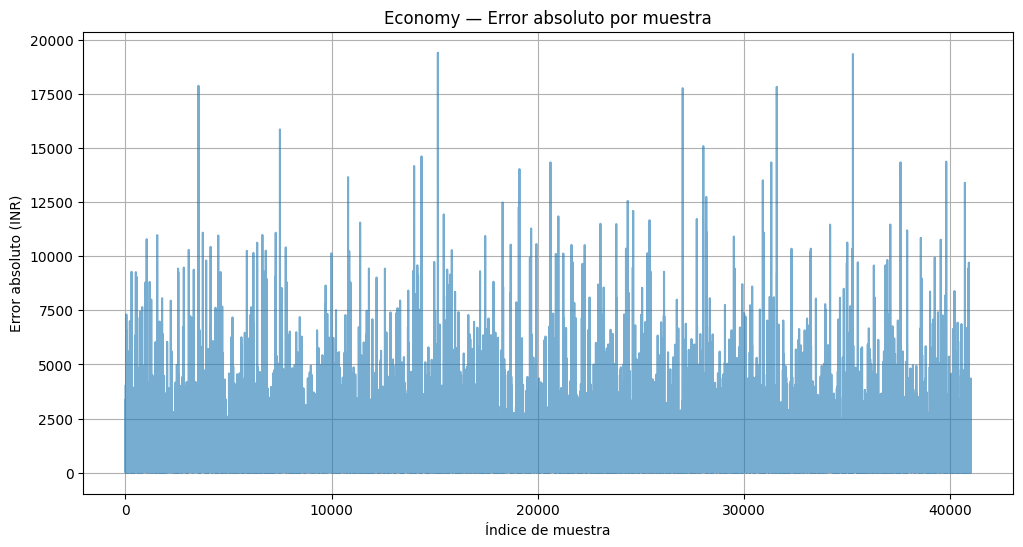

In [162]:
import matplotlib.pyplot as plt
import numpy as np

# Error absoluto
error_abs = np.abs(y_real_eco - y_pred_eco)

plt.figure(figsize=(12,6))
plt.plot(error_abs, alpha=0.6)
plt.title("Economy — Error absoluto por muestra")
plt.xlabel("Índice de muestra")
plt.ylabel("Error absoluto (INR)")
plt.grid(True)
plt.show()


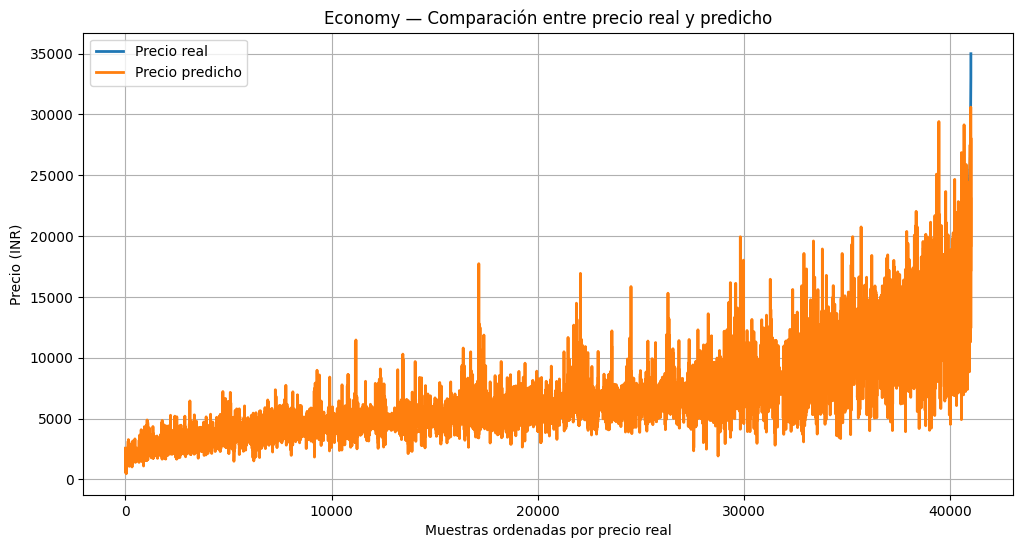

In [163]:
import matplotlib.pyplot as plt
import numpy as np

# Valores reales y predichos (Economy)
y_real_eco = y_eco_test.values
y_pred_eco = best_xgb_eco.predict(X_eco_test)

# Ordenamos por el valor real para que la línea sea legible
idx = np.argsort(y_real_eco)
y_real_sorted = y_real_eco[idx]
y_pred_sorted = y_pred_eco[idx]

plt.figure(figsize=(12,6))
plt.plot(y_real_sorted, label="Precio real", linewidth=2)
plt.plot(y_pred_sorted, label="Precio predicho", linewidth=2)
plt.title("Economy — Comparación entre precio real y predicho")
plt.xlabel("Muestras ordenadas por precio real")
plt.ylabel("Precio (INR)")
plt.legend()
plt.grid(True)
plt.show()


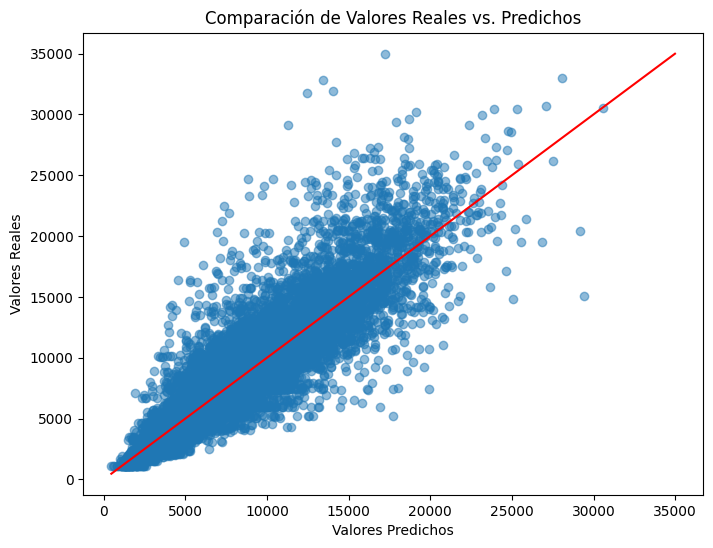

In [164]:
plot_predictions_vs_actual(y_real_eco, y_pred_eco)

In [ ]:
y_pred_eco = best_xgb_eco.predict(X_eco_test)
residuos_eco = y_eco_test - y_pred_eco

# Visualización de residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuos_eco, kde=True)
plt.title('Distribución de Residuos')
plt.xlabel('Error de Predicción')
plt.ylabel('Frecuencia')
plt.show()

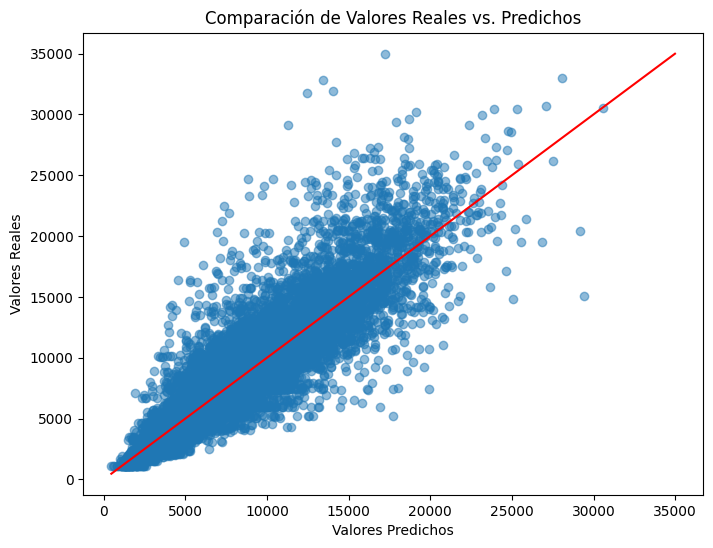

In [161]:
# Valores reales del test (Economy)
y_real_eco = y_eco_test.values

# Predicciones del modelo optimizado
y_pred_eco = best_xgb_eco.predict(X_eco_test)

# Llamada a la función
plot_predictions_vs_actual(y_real_eco, y_pred_eco)

*Los residuos siguen una distribución normal, lo que es bueno para nuestro problema de regresión, ya que los residuos se centran en el 0. Además, aunque la dispersión va aumentando según aumenta el precio, no se aprecian patrones en la gráfica de dispersión, lo que indica que el modelo captura bien las relaciones entre las predicciones y el target.*

Business

In [ ]:
y_pred_bus = best_xgb_bus.predict(X_bus_test)
residuos_bus = y_bus_test - y_pred_bus

# Visualización de residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuos_bus, kde=True)
plt.title('Distribución de Residuos')
plt.xlabel('Error de Predicción')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
# Valores reales del test (Business)
y_real_bus = y_bus_test.values

# Predicciones del modelo optimizado
y_pred_bus = best_xgb_bus.predict(X_bus_test)

# Llamada a la función
plot_predictions_vs_actual(y_real_bus, y_pred_bus)

*Los residuos para la clase Business siguen una distribución aproximadamente normal, también la dispersión empieza a ser ligeramente mayor según sube el preio, pero los puntos se ajustan bastante bien a la recta.*

# Extra

Como científicos de datos de CLA Flight Intelligence creemos que vamos a tener un porblema en los próximos web scrapping porque pensamos que los próximos datos nos vendrán sin la columna de Economy y Bussines, por lo que queremos crear un modelo de clasificación que sea capaz de clasificar los vuelos de economy y Businnes en función de sus otras Features. Todo esto para poder seguir teniendo nuestro dos dataset independientes de economy y business y utilizar el modelo de economy o bussiness que son diferentes.

In [ ]:
df_economy_cla= pd.read_csv("./src/data/economy.csv")
df_eco_cla=df_economy_cla.copy()
df_business_cla = pd.read_csv("./src/data/business.csv")
df_bus_cla=df_business_cla.copy()

In [ ]:
df_eco_cla.info()

In [ ]:
df_bus_cla.info()

Añado la columna class para separar entre Economy y Business:

In [ ]:
df_eco_cla["class"] = "economy"
df_bus_cla["class"] = "business"

In [ ]:
df_all=pd.concat([df_eco_cla, df_bus_cla], axis=0, ignore_index=True)

In [ ]:
df_all.info()

#### ETL

Utilizamos los mismos tranformes que para el problema de regresión

In [ ]:
df_all_clean=etl_pipeline.fit_transform(df_all)

In [ ]:
df_all_clean.info()

In [ ]:
df_all_clean.isna().sum()

#### **Paso 2: Mini-EDA**

**Análisis univariante**

In [ ]:
plt.figure(figsize=(12,6))
df_all_clean['airline'].value_counts().plot(kind='bar')
plt.title("Número de vuelos por aerolínea")
plt.xlabel("Aerolínea")
plt.ylabel("Cantidad de vuelos")
plt.xticks(rotation=45)
plt.show()


In [ ]:
tabla_plot = pd.crosstab(df_all_clean["airline"], df_all_clean["class"])
plt.figure(figsize=(12,6))
tabla_plot.plot(kind='bar', stacked=True, color=["blue", "red"])
plt.title("Número de vuelos por aerolínea y clase")
plt.xlabel("Aerolínea")
plt.ylabel("Cantidad de vuelos")
plt.xticks(rotation=45)
plt.show()


In [ ]:
df_all_clean.head(10)

In [ ]:
num_cols = ['price (INR)', 'duration(h)', 'stop_num', 'days_left']

**Análisis del target**

In [ ]:
class TargetExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, target):
        self.target = target
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X[[self.target]]

In [ ]:
target="class"

target_pipeline = Pipeline([
    ('extract_target', TargetExtractor(target=target))
])

target_df = target_pipeline.fit_transform(df_all_clean)

In [ ]:
freq_vuelos = df_all_clean["class"].value_counts(normalize=True).mul(100).rename("percentage").reset_index()
sns.barplot(data=freq_vuelos, x="class", y="percentage", palette="viridis")
plt.ylabel("Porcentaje (%)")
plt.title("Distribución del Target en Porcentaje")
plt.show()

**Vamos a verificar outlier**

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class OutlierDetectorIQR(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.num_cols = None
        self.bounds = {}
    
    def fit(self, X, y=None):
        self.num_cols = X.select_dtypes(include=['int64', 'float64']).columns
        
        for col in self.num_cols:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 5 * IQR
            self.bounds[col] = (lower, upper)
        
        return self
    
    def transform(self, X):
        X_out = X.copy()
        X_out["is_outlier"] = False
        
        for col in self.num_cols:
            lower, upper = self.bounds[col]
            mask = (X[col] < lower) | (X[col] > upper)
            X_out["is_outlier"] = X_out["is_outlier"] | mask
        
        return X_out

In [ ]:
from sklearn.pipeline import Pipeline

outlier_pipeline = Pipeline([
    ('outliers', OutlierDetectorIQR())
])

In [ ]:
df_all_out = outlier_pipeline.fit_transform(df_all_clean)

In [ ]:
df_all_out.head()

In [ ]:
df_all_out['is_outlier'].value_counts(normalize=True)

In [ ]:
def boxplot_variable(df, col):
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x=col, color='skyblue')
    plt.title(f"Boxplot de {col}")
    plt.show()


In [ ]:
boxplot_variable(df_all_clean, 'price (INR)')

#### **Paso 3: Split Train y Test**

In [ ]:
df_all_ml=df_all_clean.copy()

In [ ]:
df_all_ml = df_all_clean.drop(columns=["price (INR)"])


In [ ]:
X=df_all_ml.drop(columns=["class"])
y=df_all_ml["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
df_all_ml.head()

In [ ]:
print(len(X_train))
print(len(X_test))

In [ ]:
y_train.value_counts(normalize=True, dropna=False)

In [ ]:
y_test.value_counts(normalize=True, dropna=False)

#### **Paso 4: Selección de features**

In [ ]:
num_cols

In [ ]:
features_num_clas = ["duration(h)", "days_left", "stop_num" ] #"price (INR)"
print(features_num_clas)

features_cat_clas = [col for col in df_all_ml.columns if col not in features_num_clas and col != target]
'''features_cat_clas.remove("price (INR)")'''
print(features_cat_clas)

features = features_num_clas + features_cat_clas

In [ ]:
features

**Categóricas vs target_clas**

In [ ]:
target

In [ ]:
for col_cat in features_cat_clas:
    bt.plot_categorical_relationship_fin(df=df_all_ml, cat_col1=col_cat, cat_col2=target, size_group=6, relative_freq=True)

In [ ]:
#Parece haber cierta relación entre dept_time y arr_time y class

In [ ]:
for col_num in features_num_clas:
    bt.plot_categorical_numerical_relationship(df=df_all_ml, numerical_col=col_num, show_values=True, categorical_col=target)

In [ ]:
len(df_all_clean.columns)

In [ ]:
features_cat_clas

Aplico test estadistico Chi-cuadrado para determinar la relación del target con las variables categóricas

In [ ]:
from scipy.stats import chi2_contingency

for col in features_cat_clas:
    contingency_table = pd.crosstab(df_all_ml[col], df_all_ml[target])
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    print(f"Variable: {col} | p-value: {p:.5f}")

Aplico test estadistico Anova para determinar la relación del target con las variables numéricas

In [ ]:
features_num_clas

In [ ]:
target

In [ ]:
for cat_col in features_num_clas:

    valores_unicos = df_all_ml[target].unique()
    target_por_cat_col = [df_all_ml[df_all_ml[target] == categoria][cat_col] for categoria in valores_unicos]
    f_val, p_val = stats.f_oneway(*target_por_cat_col)
    print(f"{cat_col}:")
    print(f"\t Valor de F: {f_val}")
    print(f"\t p-valor: {p_val}")

ANOVA solo detecta relaciones lineales y univariantes, y por eso no sirve para decidir qué features mantener o eliminar en modelos de Machine Learning basados en árboles como XGBoost, RandomForest o LightGBM. Por lo que que no quitamos stop_num.

In [ ]:
features_num_clas

In [ ]:
features_cat_clas

In [ ]:
df_all_ml.head()

#### **Paso 5: Tratamiento de features y target**

In [ ]:
df_all_ml[features_num_clas].hist(bins=50)

In [ ]:
features_cat_clas

In [ ]:
for col in features_cat_clas:
    print(f"Para la variable {col}")
    print(df_all_clean[col].value_counts(normalize=True))
    print("------------------------------")

Aplicamos OneHotEncoder a las features categóricas través de ColumnTransformer:

In [ ]:
cat_cols = [col for col in features_cat_clas]

preprocessor_trees = ColumnTransformer([
    ("procesar_cat_OH", OneHotEncoder(handle_unknown = "ignore"), cat_cols)
], remainder = "passthrough")

# X_train_pre = preprocessor_trees.fit_transform(X_train)

Transformamos el target:

In [ ]:
y_train = y_train.map({"economy": 0, "business": 1})
y_test = y_test.map({"economy": 0, "business": 1})

In [ ]:
features

In [ ]:
X_train=X_train[features]
X_test=X_test[features]

#### **Paso 6: Baseline**

Randomforest

In [ ]:
rf = Pipeline([
    ("prep", preprocessor_trees),
    ("model", RandomForestClassifier(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

#### **Paso 7: Comparación modelos de clasificacion**

XGBoost

In [ ]:
xgb = Pipeline([
    ("prep", preprocessor_trees),
    ("model", XGBClassifier(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

LightGBM

In [ ]:
lgbm = Pipeline([
    ("prep", preprocessor_trees),
    ("model", LGBMClassifier(
        max_depth = 7,
        random_state=42,
        verbose=-1
    ))
])

Nuestra métrica principal de evaluación será la F1 debido a que da la misma importancia a ambas clases, economy y business.

In [ ]:
def eval_cv(model, X, y, name):
    scoring = {
    "f1_macro": "f1_macro",
    "balanced_accuracy" : "balanced_accuracy", 
    "roc_auc" : "roc_auc"
    #"precision" : "precision"
    #"recall" : "recall"
    
    }

    cv = cross_validate(
        model,
        X,
        y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    print(f"\nModel <{name}>")
    print("f1_macro", cv["test_f1_macro"].mean())
    print("balanced_accuracy", cv["test_balanced_accuracy"].mean())
    print("roc_auc" , cv["test_roc_auc"].mean())


In [ ]:
eval_cv(rf, X_train, y_train, "RF")
eval_cv(xgb, X_train, y_train, "XGB")
eval_cv(lgbm,X_train, y_train, "LGBM")

Ajustamos los modelos

In [ ]:
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)

In [ ]:
def eval_test(model, X_test, y_test, name):
    preds = model.predict(X_test)

    probs = model.predict_proba(X_test)[:, 1]

    f1_macro = f1_score(y_test, preds, average='macro')
    bal_acc = balanced_accuracy_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, probs)

    print(f"\n--- Clasificación: Resultados Test <{name}> ---")
    print(f"F1-Macro:          {f1_macro:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"ROC-AUC:           {roc_auc:.4f}")

#### **Paso 8: Optimización con optuna**

In [ ]:
# Definir función objetivo para Optuna

def objective(trial):

    param_grid = {
        "model__n_estimators": trial.suggest_int("model__n_estimators", 100, 1000),
        "model__max_depth": trial.suggest_int("model__max_depth", 4, 12), # Subimos profundidad para captar patrones sin precio
        "model__learning_rate": trial.suggest_float("model__learning_rate", 0.01, 0.2, log=True),
        "model__subsample": trial.suggest_float("model__subsample", 0.6, 1.0),
        "model__colsample_bytree": trial.suggest_float("model__colsample_bytree", 0.6, 1.0),
        # Añadimos este para manejar el desbalanceo del 30% Business
        "model__scale_pos_weight": trial.suggest_float("model__scale_pos_weight", 1.0, 3.0)
        }


    xgb.set_params(**param_grid)

    score = cross_val_score(
        xgb,
        X_train,
        y_train,
        cv=5,
        scoring="f1_macro", 
        n_jobs=-1
    ).mean()

    return score

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Mejores parámetros:", study.best_params)
print("Mejor F1-Macro:", study.best_value)

In [ ]:
best_params = study.best_params
best_params_pipe = {f"model__{k}": v for k, v in best_params.items()}

In [ ]:
xgb.set_params(**best_params_pipe)

In [ ]:
joblib.dump(xgb, "./src/models/xgb_best_model_clf.joblib")

In [ ]:
best_xgb = joblib.load("./src/models/xgb_best_model_clf.joblib")

In [ ]:
best_xgb.fit(X_train, y_train)

In [ ]:
eval_test(best_xgb, X_test, y_test, "XGB")

En la validación cruzada del modelo XGBoost sin optimizar se obutuvo un score medio F1 de 0.63 aproximadamente. Tras la optimización de hiperparámetros usando la librería Optuna, se mejora a un 0.7. Después de entrenar el modelo, al evaluar el conjunto de test obtenemos un F1 score de 0.71 aproximadamente, por lo tanto el modelo gereraliza bien y no se observa overfitting ni underfitting.